# 1. INTRODUCTION AND CONTEXT
The goal of this analysis is to investigate the disposable income around each Metro Station in Paris, to answer the following research questions:
-Whats the distirbution of average disposable income?
-Which Metro Line is the richest on average?
-Which Metro Line is the poorest on average?
-Which Metro Line ist the most unequal on average?

To answer this question, the following Data is used:
- Disposable Income Dataset of the French Gouverment: https://entrepot.recherche.data.gouv.fr/dataset.xhtml?persistentId=doi:10.57745/QRBINB ; The geotif raster was cropped and reprojected to a metric coordinate system using QGIS before 

- Shapefile of Stations, also provided by the french gouverment : https://www.data.gouv.fr/datasets/gares-et-stations-du-reseau-ferre-dile-de-france-par-ligne

- Shapefile of Metrolines, also provided by the french gouverment : https://www.data.gouv.fr/datasets/itineraires-de-metro-dans-openstreetmap


## METHODOLOGY
The methodology is to create a 300m buffer around the stations, using it as a simplyfied catchment area and calculate the spatial staitstic of average income. One has to note that also this approach is simplyfied, as it does not take into account the weight of each grid. So if a buffer touches 2 grids, it will be the unweighted average of both, no matter how much of which it touches. 

If a station is an interchange between several lines, it is treated as a different stations. This has one hand the reason, that some tracks between lines are quite far from each other, on the other hand there are actually some differences notable between the same staiton

## STRUCTURE OF OUTCOMES 
The project has the following structure :
1. Introduction and Context
2. Imports
3. Data Processing
4. Data Analysis
       
    -4.1 Income Distribution

    -4.2 Grouping Stations per Line 

    -4.3 Income per Line
    
    -4.4 Inequality per Line

5. Regression for Line X
6. Conclusion

# 2. IMPORTS
Import Tools, Functions and Data

In [23]:
#Pathfinder
import sys
import os
sys.path.append(os.path.abspath(".."))

#Packages
import pandas as pd
import matplotlib.pyplot as plt

#Functions
from src.load_data import load_stations, load_income_grid
from src.raster_analysis import extract_mean_raster_value
from src.spatial import reproject_to_metric, create_buffers


In [24]:
#Import Station Data
stations = load_stations("../data/raw/Stations/emplacement-des-gares-idf/emplacement-des-gares-idf.shp")
stations.head()
stations = reproject_to_metric(stations)
stations = stations[stations["mode"] == "METRO"]
stations.shape

(405, 27)

## 3. DATA PROCESSING
Steps: Create the Buffers, Do the raster analysis,create Maps to control
Outcome: 

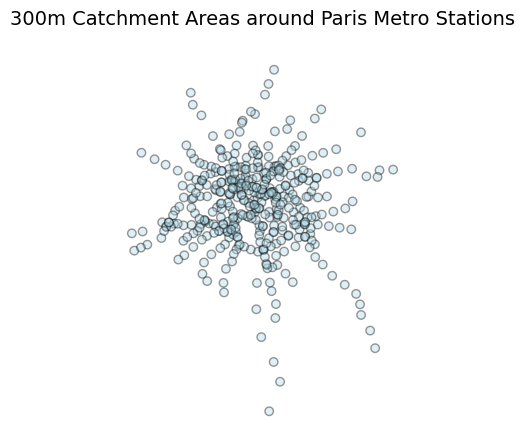

In [25]:
#CREATE THE BUFFERS:
station_buffers = create_buffers(stations, 300)

#CREATE A STATIC MAP
fig, ax = plt.subplots(figsize=(5, 5))

station_buffers.plot(
    ax=ax,
    alpha=0.4,
    edgecolor="black",
    color="lightblue"
)

ax.set_title("300m Catchment Areas around Paris Metro Stations", fontsize=14)
ax.set_axis_off()

plt.show()

#CREATE AN INTERACTIVE HTML MAP 
m = station_buffers.explore()
m.save("../outputs/1_MAP_Network.html")




In [26]:
#RASTERANALYSIS

income_raster_path = "../data/raw/TIF/FRA_disp_inc_2015_EPSG_2154_crop.tif"
station_buffers_income = extract_mean_raster_value(
    station_buffers,
    raster_path=income_raster_path,
    value_column="income_mean"
)

station_buffers_income["income_mean"].isna().sum()
station_buffers_income["income_mean"].describe()

count      405.000000
mean     32210.012566
std       5920.263834
min      18313.011719
25%      27469.699219
50%      32046.585938
75%      36723.921875
max      44404.005208
Name: income_mean, dtype: float64

PLAUSIBILITY CHECK

In [27]:
#10 richest Stations
top_stations = station_buffers_income.sort_values(
    by="income_mean",
    ascending=False
).head(10)

top_stations[["nom_gares", "indice_lig", "income_mean"]]

,nom_gares,indice_lig,income_mean
214,Monceau,2,44404.005208
1220,Villiers,2,43928.445312
476,Villiers,3,43928.445312
1114,Malesherbes,3,43893.585938
728,Courcelles,2,43458.015625
835,Ternes,2,43458.015625
856,Jasmin,9,42903.179688
1121,Pont de Neuilly,1,42334.253906
625,Michel Ange-Auteuil,9,42263.179688
861,Michel Ange-Auteuil,10,42263.179688


In [28]:
# 10 Poorest Stations
bottom_stations = station_buffers_income.sort_values(
    by="income_mean",
    ascending=True
).head(10)

bottom_stations[["nom_gares", "indice_lig", "income_mean"]]

,nom_gares,indice_lig,income_mean
465,Aimé Césaire,12,18313.011719
724,Mairie d'Aubervilliers,12,18417.355469
432,Front Populaire,12,19201.949219
937,Fort d'Aubervilliers,7,19592.882812
934,La Courneuve 8 Mai 1945,7,19598.752604
1172,Aubervilliers Pantin - Quatre Chemins,7,19958.837240
611,Saint-Denis - Porte de Paris,13,20616.679688
612,Saint-Denis - Université,13,20719.195312
227,Basilique de Saint-Denis,13,20913.832031
1097,Les Courtilles,13,21405.867188


Since the richest stations are concentrated in the inner northwest of Paris and the poorest stations around the north-eastern banlieu, the result seems to be plausibel 

# 4. Analysis
The following chapter conducts the spatial analysis

## 4.1 Income Distribution
The first analysis will focus on the broad stats of the analysis, showing:

4.1.1  Distirbution Grid Cells per Station
4.1.2  Distribution Income Intervalls
4.1.3  Heatmap showing the Intervalls

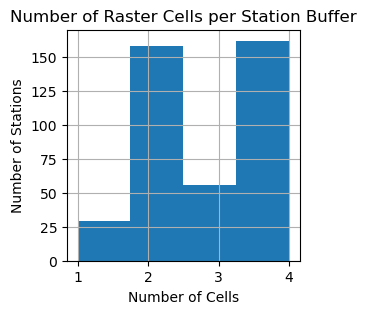

In [29]:
#4.1.1 Distribution Grid Cells per Station
plt.figure(figsize=(3,3))
station_buffers_income["n_cells"].hist(bins=4)
plt.title("Number of Raster Cells per Station Buffer")
plt.xlabel("Number of Cells")
plt.ylabel("Number of Stations")

plt.show()

The majority of cells either intersect with 2 or with 4 raster grid cells

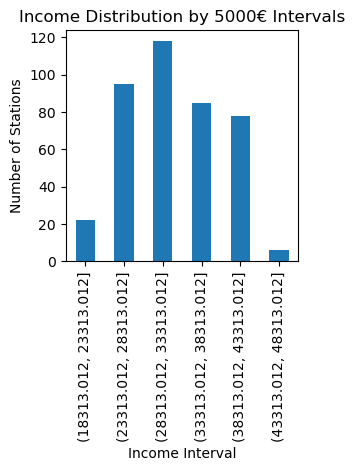

In [30]:
#4.1.2 Distribution in Intervals
df = station_buffers_income.dropna(subset=["income_mean"]).copy()
min_income = df["income_mean"].min()
max_income = df["income_mean"].max()

interval_width = 5000

n_intervals = int((max_income - min_income) / interval_width) + 1

bins = [min_income + i * interval_width for i in range(n_intervals + 1)]

df["income_interval"] = pd.cut(df["income_mean"], bins=bins)

interval_distribution = df["income_interval"].value_counts().sort_index()

interval_distribution.plot(kind="bar", figsize=(3,3))

plt.title("Income Distribution by 5000€ Intervals")
plt.xlabel("Income Interval")
plt.ylabel("Number of Stations")

plt.xticks(rotation=90)
plt.show()

The distribution is approximately bell-shaped and right skewed

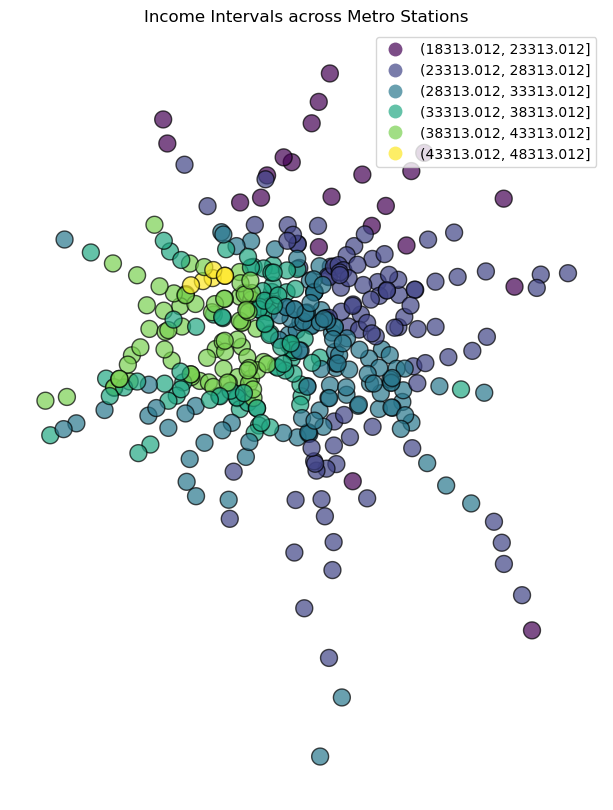

In [31]:
#4.1.3 Heatmap showing Intervals of the Station

#Static Map in the Notebook
fig, ax = plt.subplots(figsize=(10,10))

df.plot(
    column="income_interval",
    cmap="viridis",
    legend=True,
    ax=ax,
    edgecolor="black",
    alpha=0.7
)

ax.set_title("Income Intervals across Metro Stations")
ax.set_axis_off()

plt.show()

The heatmap confirms the intuition, that the stations in the inner west have on average a higher disposable income, while the rest of paris is in the middle region, with the north-eastern edges and the banlieu beeing the lowest group.

In [32]:
#Interactive Map in the 
df["income_interval"] = df["income_interval"].astype(str)

m = df.explore(
    column="income_interval",
    cmap="viridis"
)

m.save("../outputs/4_1_3_income_intervals_map.html")

## 4.2 Grouping Stations by Line
Now the stations are grouped by lines

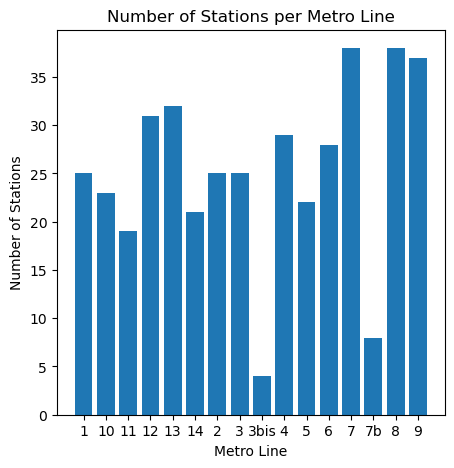

In [33]:
#Sorting the Lines
stations_per_line = df.groupby("indice_lig").size().reset_index(name="n_stations")
stations_per_line = stations_per_line.sort_values(by="indice_lig")

#Histogram 
plt.figure(figsize=(5,5))

plt.bar(
    stations_per_line["indice_lig"],
    stations_per_line["n_stations"]
)

plt.title("Number of Stations per Metro Line")
plt.xlabel("Metro Line")
plt.ylabel("Number of Stations")

plt.show()

In [34]:
filtered = stations_per_line[
    ~stations_per_line["indice_lig"].isin(["3bis", "7b"])
].copy()

min_stations = filtered["n_stations"].min()
max_stations = filtered["n_stations"].max()
mean_stations = filtered["n_stations"].mean()

min_stations, max_stations, mean_stations

print(f"Min stations: {min_stations}")
print(f"Max stations: {max_stations}")
print(f"Average stations: {mean_stations:.2f}")

Min stations: 19
Max stations: 38
Average stations: 28.07


Besides the 2 branch lines 3bis and 7b, most all of the stations are in a range of 19-38, with an average of 28 Stations

## 4.3 Income per Line
Now we sort the grouped lines by their average income

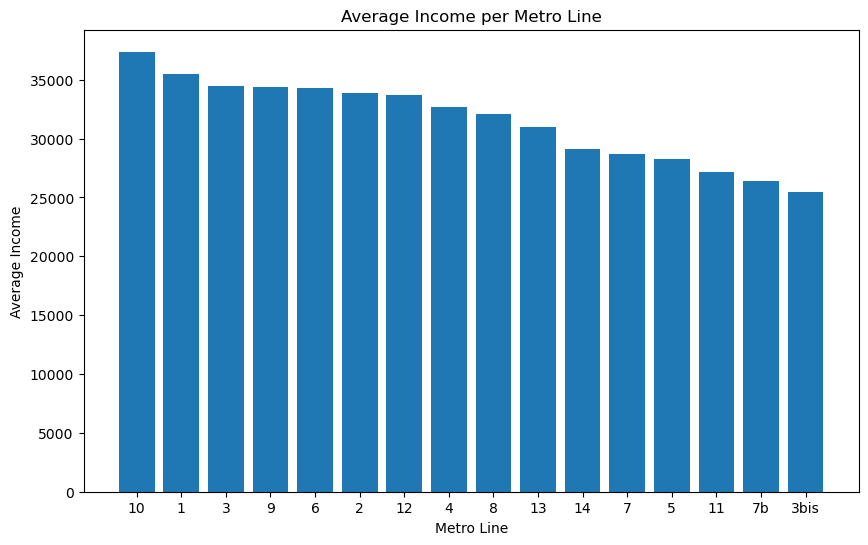

In [35]:
#Average Income
line_income = df.groupby("indice_lig")["income_mean"].mean().reset_index()
line_income = line_income.rename(columns={"income_mean": "mean_income"})

#Sort by value
line_income["line_num"] = line_income["indice_lig"].str.extract(r"(\d+)").astype(int)
line_income = line_income.sort_values(by=["mean_income"], ascending=False)

#Barchart
plt.figure(figsize=(10,6))

plt.bar(
    line_income["indice_lig"],
    line_income["mean_income"]
)

plt.title("Average Income per Metro Line")
plt.xlabel("Metro Line")
plt.ylabel("Average Income")

plt.xticks(rotation=0)

plt.show()

One can observes, that the two branch lines do have the lowest income. 
To get a better overview, the stations and lines will be combined in the following maps.

In [ ]:
#Metrolines with average income = colorgrading and thickness

## 4.4 Inequality per Line
#Unequality per Line
#Interpretation

# 5. Regression

The goal of this exerceise is to investigate one choosen line and investigate wheather one can observe a regression for the income and the distance from the center. 
Since there was no open-source dataset that included the exact kilometer point at which each station is in the alignment, one has to work its way around it. From the given information in the station dataset, the most useful will therefore probably be the coordinates, together with some assumptions. 

On therefore needs to choose lines, in which the x or the y axis dictates the distance from the center, as the alignment functions as a north-south or east-west axis. Because of their characteristics, two lines are choosen:

- Metro Line 4 : North South Axis, as shown below, the income characeteristics of this line is, that the north and south are in the lower quantiles while the center is in the upper and middle quantiles. The first instinct would therefore be, that the income would look parabolic

- Meto Line 1: East West Axis, as shown below, one would assume a similar but less central distirbution, where beginning from the east the metro connects lower/middle income station with westward increasing income groups untill it reaches it peak near Etoile and declines untill Defense

Both lines pass through the station "Chatelet" , which is taken as a center due to its geographic location and importance as central node in the parisian transit system